<a href="https://colab.research.google.com/github/Memucan-ctrl/codveda-ml-internship/blob/main/level3_task3_neural_network/neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Level 3 — Task 3: Neural Network with TensorFlow/Keras

Dataset: MNIST (handwritten digits)
Architecture: Flatten → Dense(128, relu) → Dropout(0.2) → Dense(64, relu) → Dense(10, softmax)
Optimizer: Adam, Loss: sparse categorical crossentropy
Results: Test accuracy ≈ 0.978 after 10 epochs
Insight: Train/val loss curves converge cleanly with no overfitting.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 - 4s - 9ms/step - accuracy: 0.8820 - loss: 0.4068 - val_accuracy: 0.9620 - val_loss: 0.1380
Epoch 2/10
422/422 - 5s - 11ms/step - accuracy: 0.9475 - loss: 0.1740 - val_accuracy: 0.9703 - val_loss: 0.1010
Epoch 3/10
422/422 - 2s - 5ms/step - accuracy: 0.9604 - loss: 0.1301 - val_accuracy: 0.9747 - val_loss: 0.0859
Epoch 4/10
422/422 - 2s - 5ms/step - accuracy: 0.9677 - loss: 0.1043 - val_accuracy: 0.9785 - val_loss: 0.0756
Epoch 5/10
422/422 - 2s - 6ms/step - accuracy: 0.9739 - loss: 0.0863 - val_accuracy: 0.9768 - val_loss: 0.0785
Epoch 6/10
422/422 - 4s - 10ms/step - accuracy: 0.9756 - loss: 0.0779 - val_accuracy: 0.9785 - val_loss: 0.0741
Epoch 7/10
422/422 - 2s - 5ms/step - accuracy: 0.9777 - loss: 0.0685 - val_accuracy: 0.9790 - val_loss: 0.0715
Epoch 8/10
422/422 - 3s - 6ms/step - accuracy: 0.9806 - loss: 0.0622 - val_accuracy: 0.9812 - val_loss: 0.0667
Epoch 9/10
422/422 - 2s - 5ms/step - accuracy: 0.9827 - loss: 0.0543 - val_accuracy: 0.9818 - val_loss: 0.0717

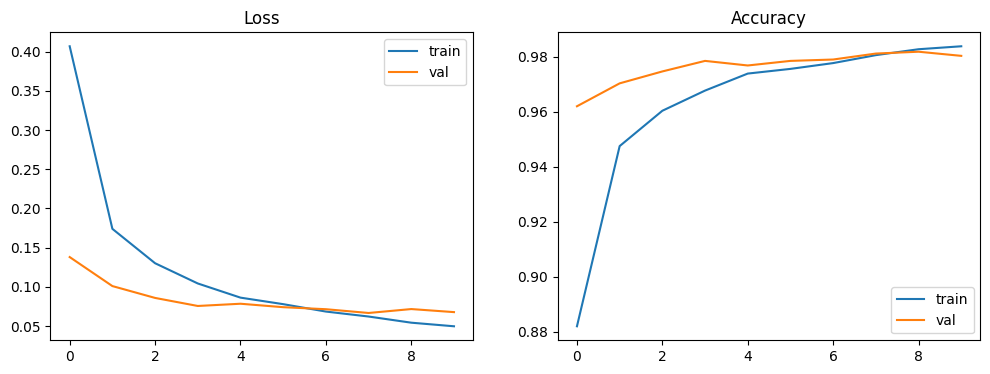

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_train, validation_split=0.1,
                    epochs=10, batch_size=128, verbose=2)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', test_acc)

# Plot loss/accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.show()